In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load all files
train = pd.read_csv('./Data/train.csv')
center_info = pd.read_csv('./Data/fulfilment_center_info.csv')
meal_info = pd.read_csv('./Data/meal_info.csv')

In [3]:
# Quick look at each before merging
print(train.head())
print('-'*40)
print(center_info.head())
print('-'*40)
print(meal_info.head())
print('-'*40)

        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2                      0                  0         189  
3                      0                  0          54  
4                      0                  0          40  
----------------------------------------
   center_id  city_code  region_code center_type  op_area
0         11        679           56      TYPE_A      3.7
1         13        590           56      TYPE_B      6.7
2        124        590     

In [4]:
# Left Join train with center_info on center_id
df = train.merge(center_info, on='center_id', how='left')

# Left Join that with meal_info on meal_id
df = df.merge(meal_info, on='meal_id', how='left')

In [5]:
# Now Lets view the Data
print('-'*50)
print(df.shape)
print('-'*50)
print(df.head())
print('-'*50)
print(df.info())
print('-'*50)
print(df.describe())

--------------------------------------------------
(456548, 15)
--------------------------------------------------
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  city_code  \
0                      0                  0         177        647   
1                      0                  0         270        647   
2                      0                  0         189        647   
3                      0                  0          54        647   
4                      0                  0          40        647   

   region_code center_type  op_area   category cuisine 

In [6]:
print(df.duplicated().sum())

0


In [7]:
print(df.isnull().sum())

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64


## Univariate Analysis

In [8]:
# Sanity check: checkout price should never exceed base price (that would mean a "negative discount")
print((df['checkout_price'] > df['base_price']).sum())

# This Means that we got Loss in 116101 orders

116101


In [9]:
# Sanity check: no negative prices or negative orders
print((df['checkout_price'] < 0).sum())
print((df['num_orders'] < 0).sum())

0
0


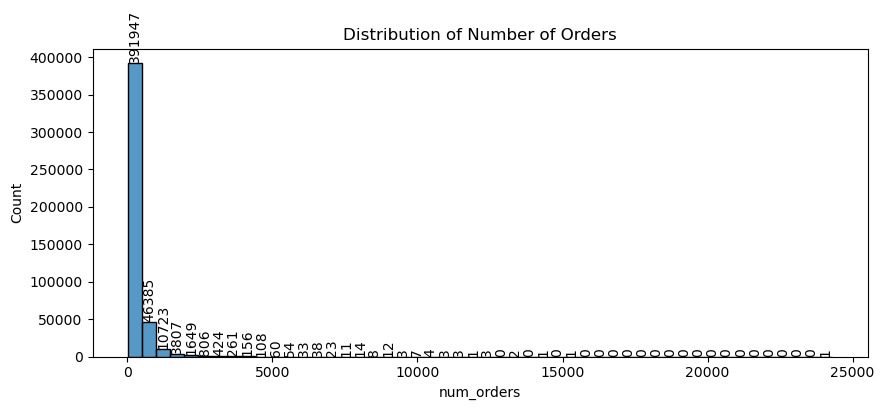

In [10]:
# Histogram - see the shape/skew
plt.figure(figsize=(10,4))
ax = sns.histplot(df['num_orders'], bins=50)
# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container,rotation=90)

plt.title('Distribution of Number of Orders')
plt.savefig('./Charts/01_num_orders_hist.png', dpi=150, bbox_inches='tight')
plt.show()

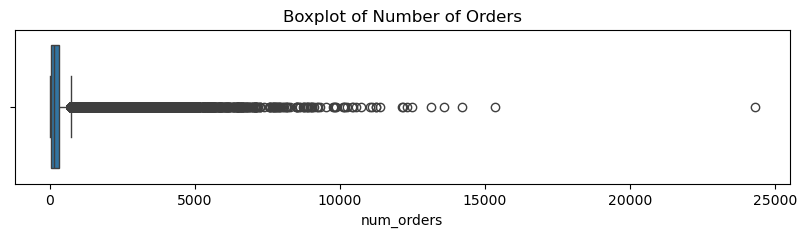

In [23]:
# Boxplot - see outliers visually
plt.figure(figsize=(10,2))
sns.boxplot(x=df['num_orders'])
plt.title('Boxplot of Number of Orders')
plt.savefig('./Charts/02_num_orders_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
Q1 = df['num_orders'].quantile(0.25)
print(Q1)

54.0


In [28]:
Q3 = df['num_orders'].quantile(0.75)
print(Q3)

324.0


In [29]:
# Here the values more than and lower than these values are considered as outlier
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(lower,upper)

NameError: name 'IQR' is not defined

In [30]:
# IQR method to quantify outliers
Q1 = df['num_orders'].quantile(0.25)
Q3 = df['num_orders'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['num_orders'] < lower) | (df['num_orders'] > upper)]
print(f"Number of outliers: {len(outliers)} out of {len(df)}")
print(f"Outlier bounds: {lower} to {upper}")

Number of outliers: 32937 out of 456548
Outlier bounds: -351.0 to 729.0


In [31]:
# What do the outlier rows look like?
print(outliers['category'].value_counts().head())
print(outliers['emailer_for_promotion'].mean())  # compare to df['emailer_for_promotion'].mean()
print(outliers['homepage_featured'].mean())      # compare to df['homepage_featured'].mean()

category
Beverages    13614
Rice Bowl     8137
Sandwich      5769
Salad         2401
Pizza         1313
Name: count, dtype: int64
0.2844217749036039
0.38385402434951577


In [32]:
print(df['emailer_for_promotion'].mean())
print(df['homepage_featured'].mean())

0.08115247465764827
0.10919990888143197


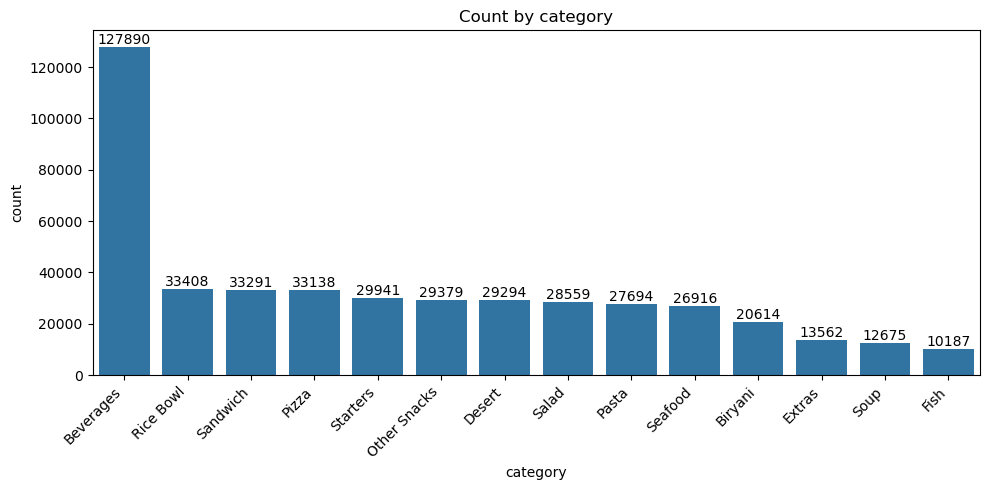

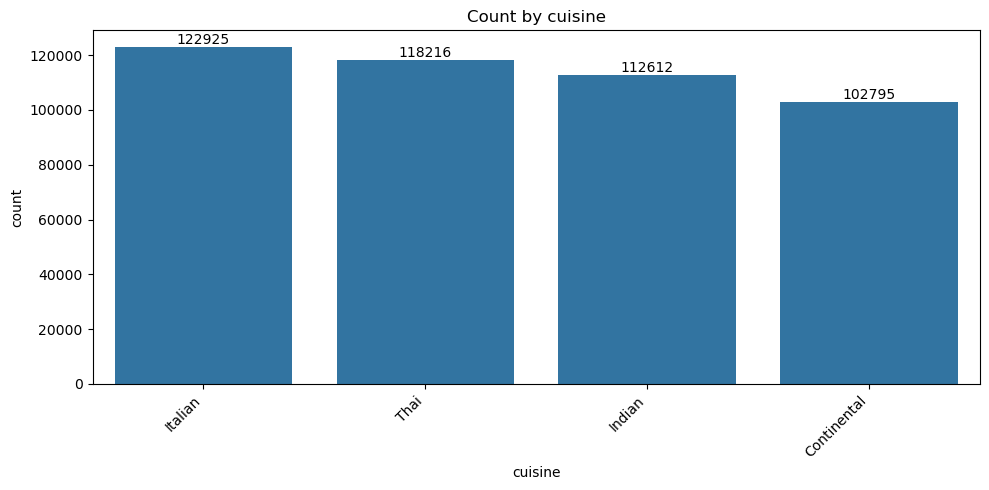

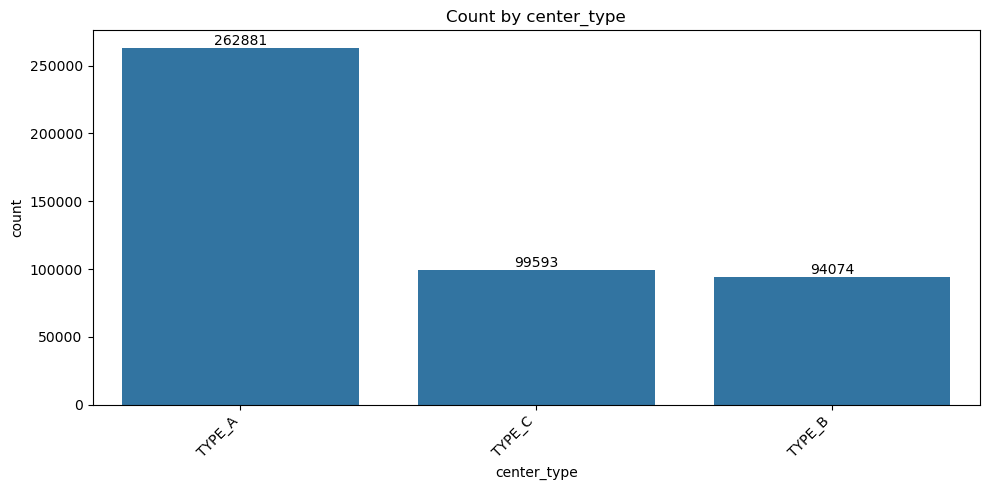

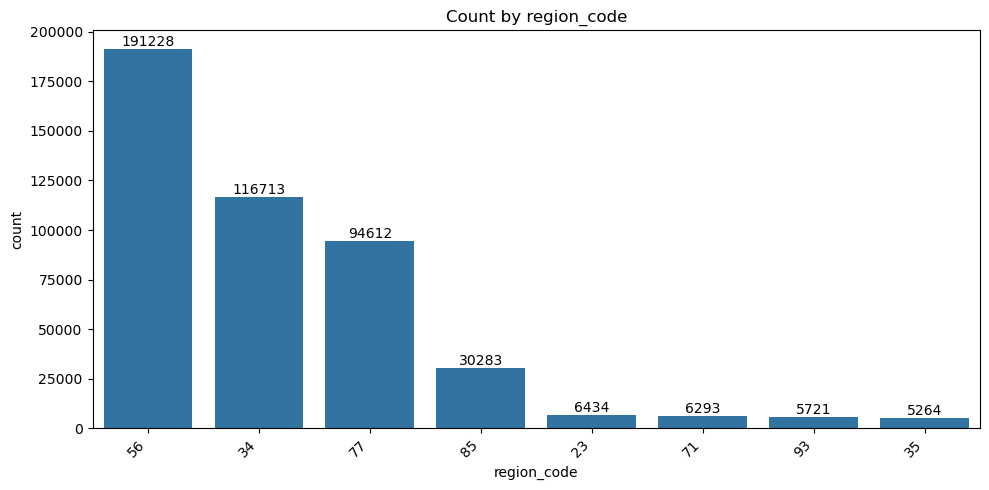

In [24]:
for col in ['category', 'cuisine', 'center_type', 'region_code']:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    for container in ax.containers:
        ax.bar_label(container)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Count by {col}')
    plt.tight_layout()
    plt.savefig(f'charts/count_by_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

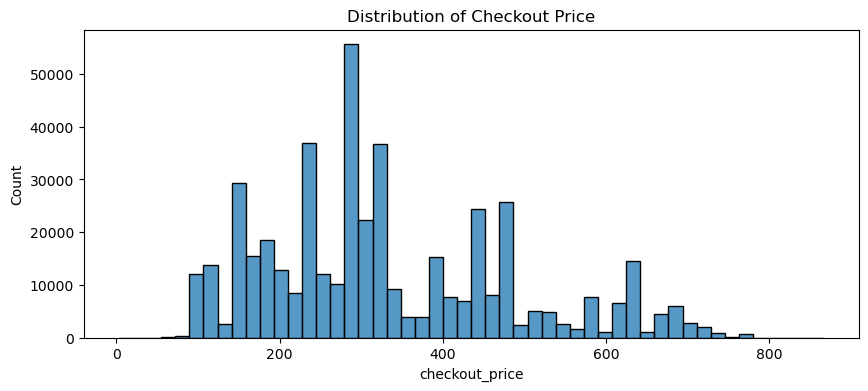

In [22]:
# Histogram - see the shape/skew
plt.figure(figsize=(10,4))
ax = sns.histplot(df['checkout_price'], bins=50)

plt.title('Distribution of Checkout Price')
plt.savefig('./Charts/07_checkoutprice_hist.png', dpi=150, bbox_inches='tight')
plt.show()

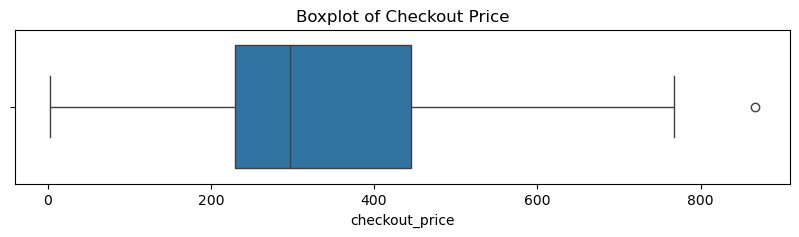

In [21]:
# Boxplot - see outliers visually
plt.figure(figsize=(10,2))
sns.boxplot(x=df['checkout_price'])
plt.title('Boxplot of Checkout Price')
plt.savefig('./Charts/08_checkoutprice_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


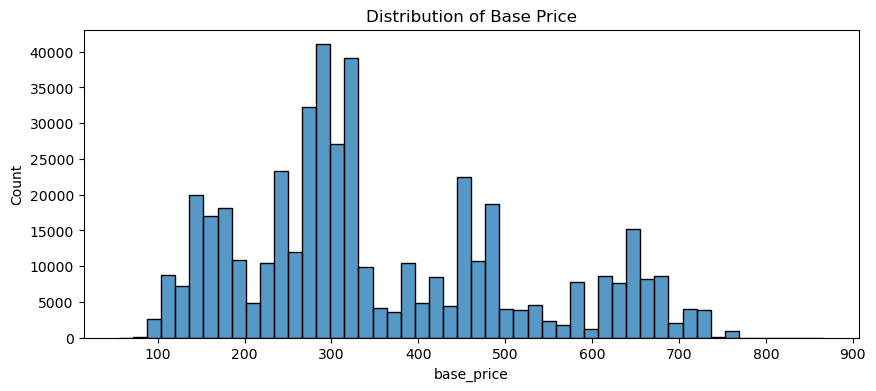

In [20]:
# Histogram - see the shape/skew
plt.figure(figsize=(10,4))
ax = sns.histplot(df['base_price'], bins=50)

plt.title('Distribution of Base Price')
plt.savefig('./Charts/09_baseprice_hist.png', dpi=150, bbox_inches='tight')
plt.show()

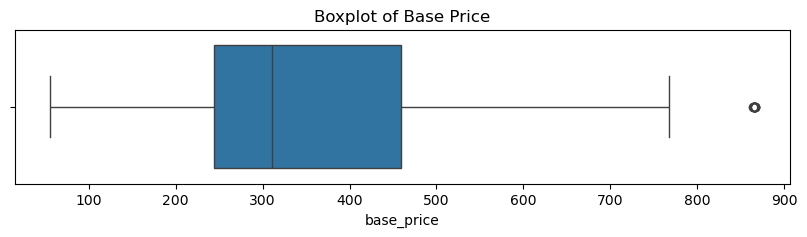

In [19]:
# Boxplot - see outliers visually
plt.figure(figsize=(10,2))
sns.boxplot(x=df['base_price'])
plt.title('Boxplot of Base Price')
plt.savefig('./Charts/10_baseprice_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Result of Univariate
- Here We got to know that 7.2% of the data flagged as Outliers
- The lower bound (-351) is meaningless here since num_orders can't be negative — so all 32,937 outliers are on the high side (orders > 729 in a week for that meal-center combo).
- Also we have noticed emailer_for_promotion or homepage_featured rates are noticeably higher in the outliers than the overall dataset average (0.081 and 0.109), that's a strong finding — "high-demand spikes are strongly associated with promotions"

In [38]:
# Compare outlier rows to the overall dataset
print("Category breakdown in outliers:")
print(outliers['category'].value_counts().head())

print("\nPromotion rate comparison:")
print(f"Overall emailer_for_promotion rate: {df['emailer_for_promotion'].mean():.3f}")
print(f"Outlier emailer_for_promotion rate: {outliers['emailer_for_promotion'].mean():.3f}")

print(f"\nOverall homepage_featured rate: {df['homepage_featured'].mean():.3f}")
print(f"Outlier homepage_featured rate: {outliers['homepage_featured'].mean():.3f}")

Category breakdown in outliers:
category
Beverages    13614
Rice Bowl     8137
Sandwich      5769
Salad         2401
Pizza         1313
Name: count, dtype: int64

Promotion rate comparison:
Overall emailer_for_promotion rate: 0.081
Outlier emailer_for_promotion rate: 0.284

Overall homepage_featured rate: 0.109
Outlier homepage_featured rate: 0.384


## Bivariate Analysis

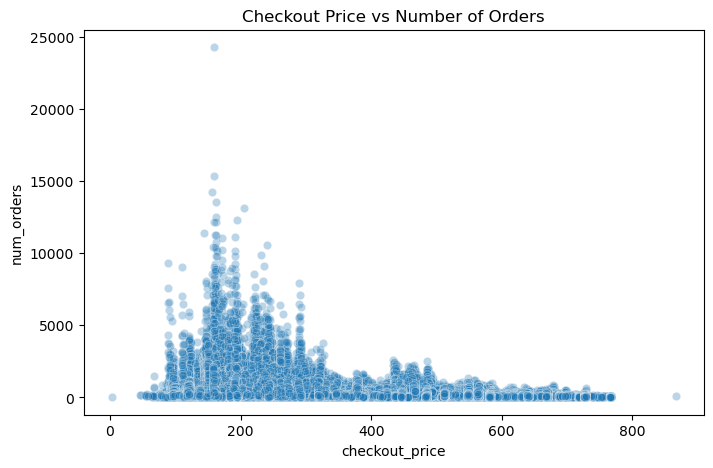

Correlation: -0.28210835168085563


In [18]:
# 1. checkout_price vs num_orders (does price affect demand?)
plt.figure(figsize=(8,5))
sns.scatterplot(x='checkout_price', y='num_orders', data=df, alpha=0.3)
plt.title('Checkout Price vs Number of Orders')
plt.savefig('./Charts/11_price_vs_orders_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation:", df['checkout_price'].corr(df['num_orders']))


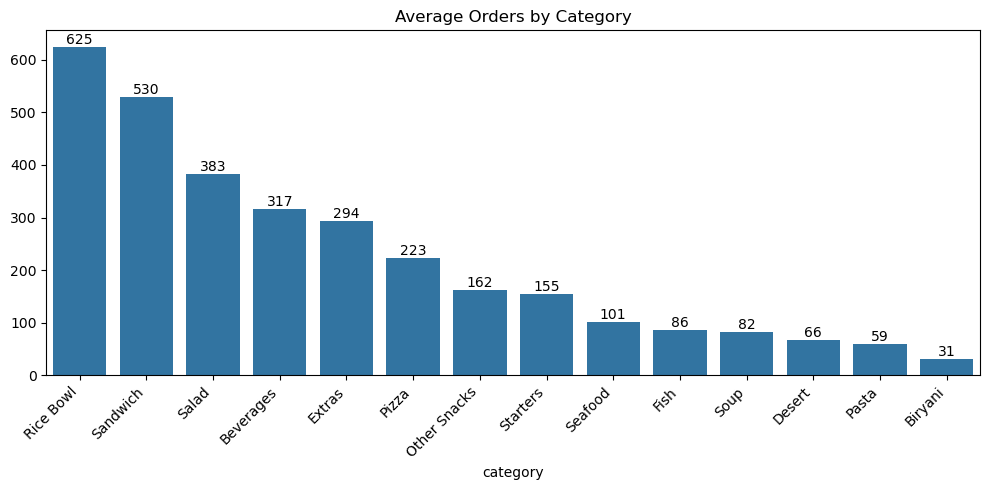

In [17]:
# 2. category vs average num_orders
plt.figure(figsize=(10,5))
avg_by_cat = df.groupby('category')['num_orders'].mean().sort_values(ascending=False)
ax = sns.barplot(x=avg_by_cat.index, y=avg_by_cat.values)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.xticks(rotation=45, ha='right')
plt.title('Average Orders by Category')
plt.tight_layout()
plt.savefig('./Charts/12_avgorders_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

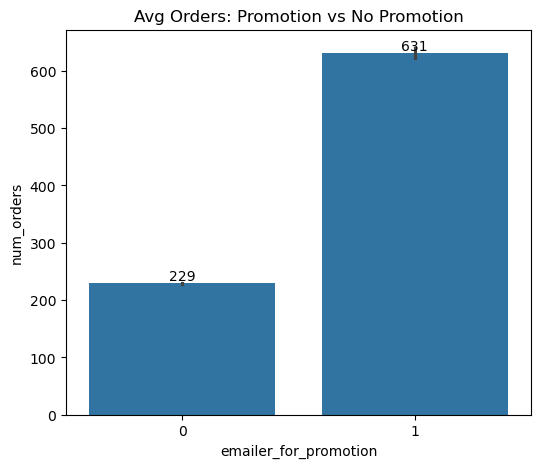

In [16]:
# 3. Does promotion actually increase orders?
plt.figure(figsize=(6,5))
ax = sns.barplot(x='emailer_for_promotion', y='num_orders', data=df)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.title('Avg Orders: Promotion vs No Promotion')
plt.savefig('./Charts/13_promo_vs_orders.png', dpi=150, bbox_inches='tight')
plt.show()

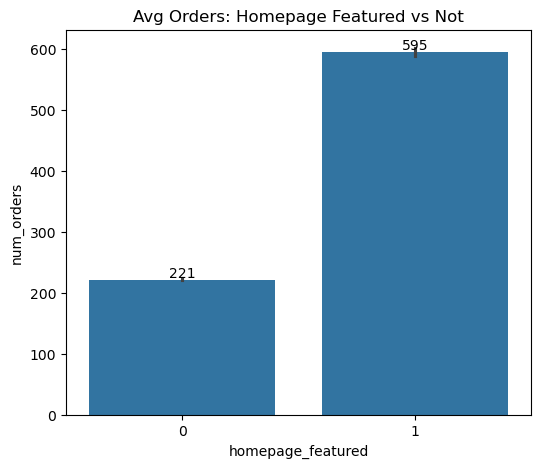

In [15]:
# 3. Does Homepage Feature increase orders?
plt.figure(figsize=(6,5))
ax = sns.barplot(x='homepage_featured', y='num_orders', data=df)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.title('Avg Orders: Homepage Featured vs Not')
plt.savefig('./Charts/14_homepage_vs_orders.png', dpi=150, bbox_inches='tight')
plt.show()

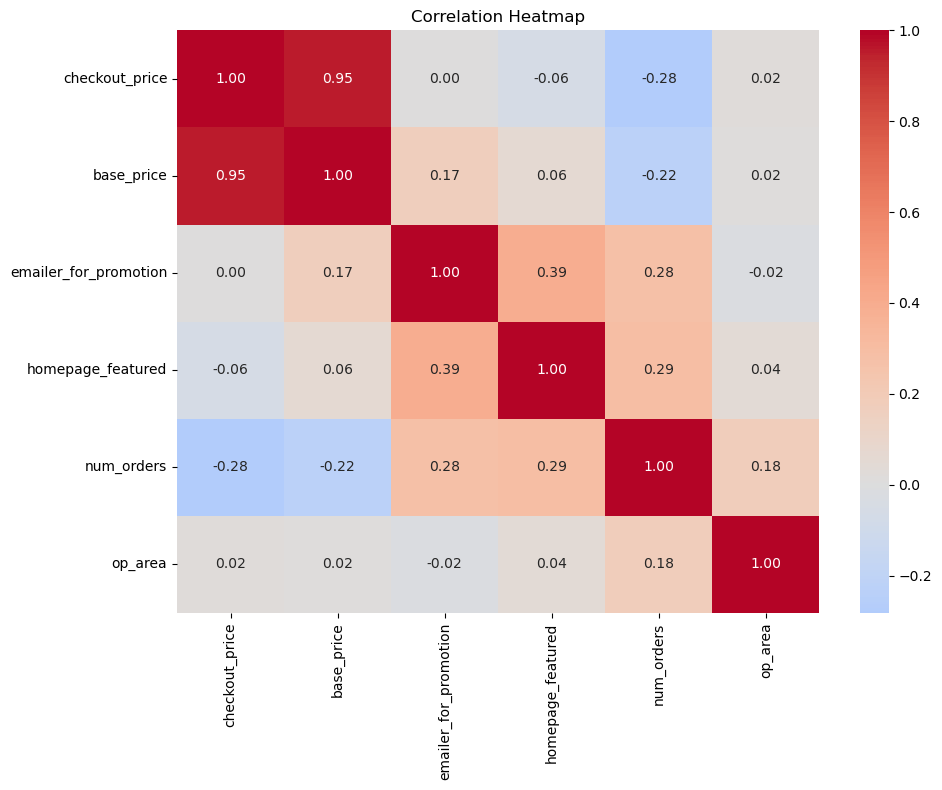

In [14]:
# 1. Correlation heatmap - see all numeric relationships at once
plt.figure(figsize=(10,8))
numeric_cols = ['checkout_price', 'base_price', 'emailer_for_promotion', 
                 'homepage_featured', 'num_orders', 'op_area']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('./Charts/15_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


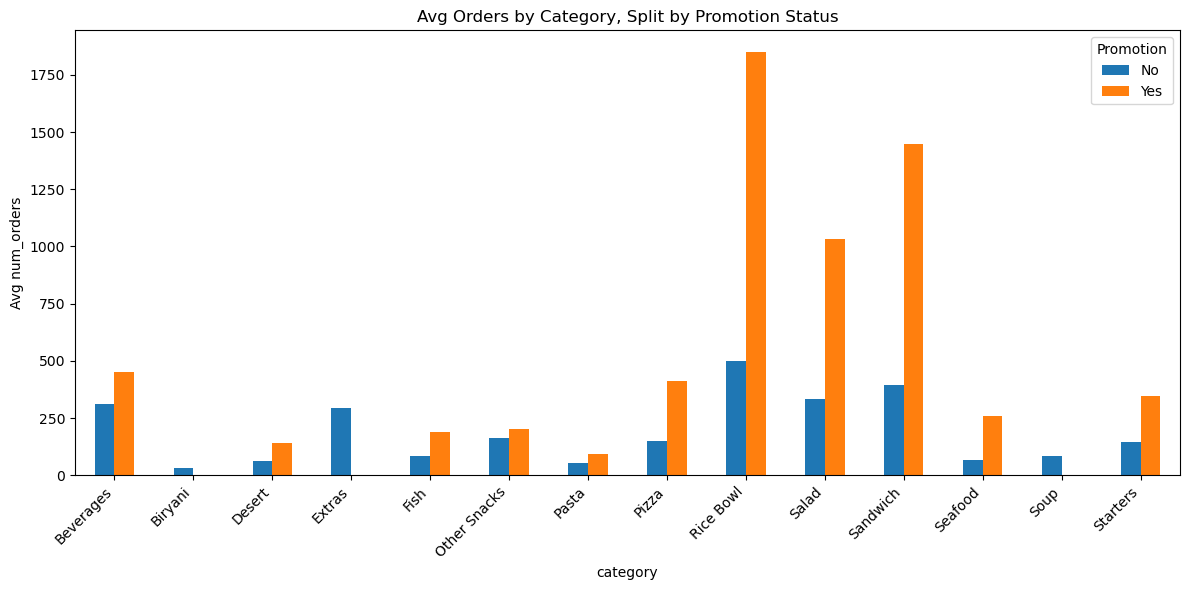

In [13]:
# 2. Does promotion effect differ by category? (3 variables: category, promotion, num_orders)
plt.figure(figsize=(12,6))
promo_by_cat = df.groupby(['category', 'emailer_for_promotion'])['num_orders'].mean().unstack()
promo_by_cat.plot(kind='bar', ax=plt.gca())
plt.title('Avg Orders by Category, Split by Promotion Status')
plt.ylabel('Avg num_orders')
plt.legend(title='Promotion', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./Charts/16_category_promo_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

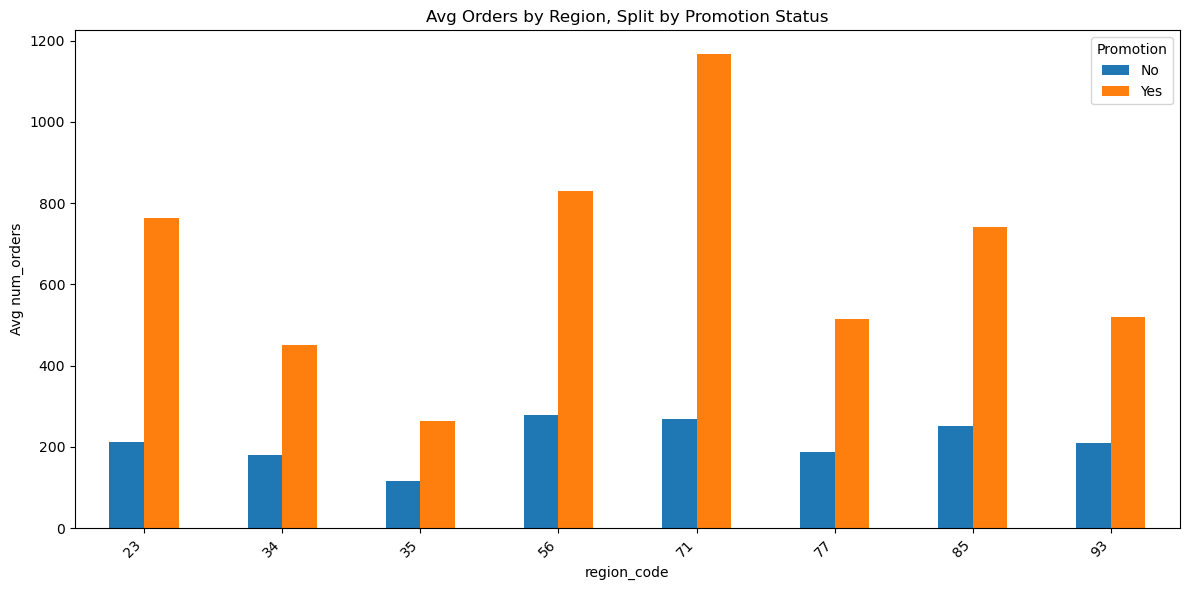

In [12]:
# 3. Does promotion effect differ by region? (3 variables: region, promotion, num_orders)
plt.figure(figsize=(12,6))
promo_by_region = df.groupby(['region_code', 'emailer_for_promotion'])['num_orders'].mean().unstack()
promo_by_region.plot(kind='bar', ax=plt.gca())
plt.title('Avg Orders by Region, Split by Promotion Status')
plt.ylabel('Avg num_orders')
plt.legend(title='Promotion', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./Charts/17_region_promo_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

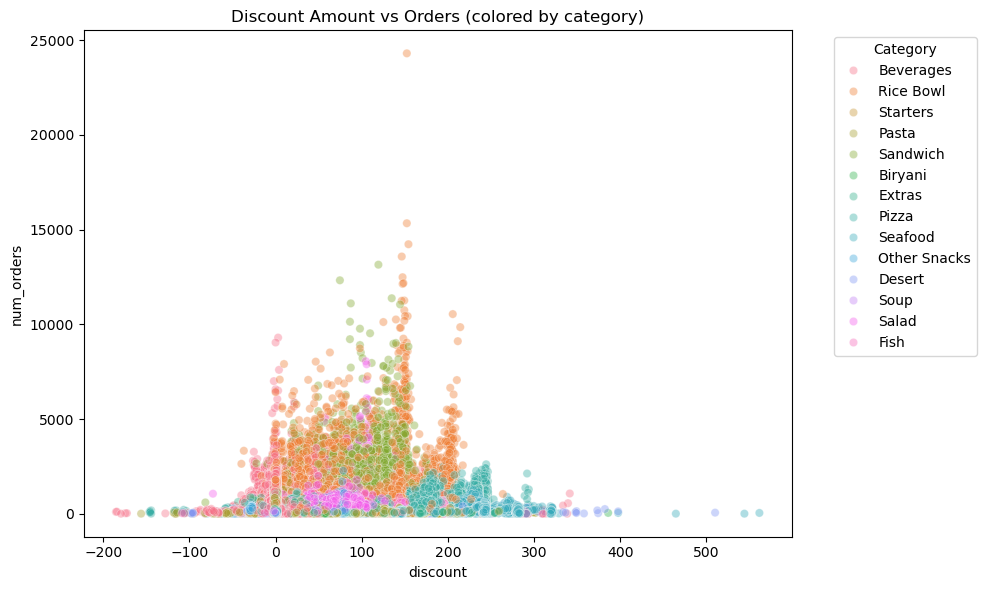

In [11]:
# 4. Discount amount vs demand, colored by category (numeric + numeric + categorical)
df['discount'] = df['base_price'] - df['checkout_price']
plt.figure(figsize=(10,6))
sns.scatterplot(x='discount', y='num_orders', hue='category', data=df, alpha=0.4)
plt.title('Discount Amount vs Orders (colored by category)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Category')
plt.tight_layout()
plt.savefig('./Charts/18_discount_vs_orders_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
print((df['discount'] < 0).sum())
df[df['discount'] < 0][['category','base_price','checkout_price','discount']].head()

116101


,category,base_price,checkout_price,discount
1,Beverages,135.83,136.83,-1.0
4,Beverages,242.50,243.50,-1.0
8,Beverages,192.06,193.06,-1.0
12,Rice Bowl,310.43,311.43,-1.0
15,Starters,281.33,282.33,-1.0


In [59]:
# Confirm it's really always exactly -1.0
print(df[df['discount'] < 0]['discount'].value_counts())


discount
-1.00      73668
-2.00      36902
-0.97        330
-1.97        221
-0.03        218
           ...  
-31.10         1
-21.28         1
-156.11        1
-118.34        1
-73.66         1
Name: count, Length: 699, dtype: int64


In [60]:

# Does this pattern correlate with anything - category, center_type, specific week?
print(df[df['discount'] < 0]['category'].value_counts())
print(df[df['discount'] < 0]['center_type'].value_counts())
print(df[df['discount'] < 0]['week'].describe())

category
Beverages       34293
Starters         9087
Sandwich         8843
Rice Bowl        8260
Salad            8258
Desert           7068
Pizza            6757
Other Snacks     6651
Seafood          6374
Pasta            6031
Biryani          5876
Soup             3382
Fish             3082
Extras           2139
Name: count, dtype: int64
center_type
TYPE_A    66963
TYPE_C    24780
TYPE_B    24358
Name: count, dtype: int64
count    116101.000000
mean         75.629142
std          41.369195
min           1.000000
25%          41.000000
50%          76.000000
75%         111.000000
max         145.000000
Name: week, dtype: float64
